# QR Eigenvalue Extrapolation via BBPN-SPRE

## Four Methods: Independent · Global · Sequential

### Mathematical Setup

Unshifted QR iteration on $A \in \mathbb{R}^{n \times n}$ produces a sequence of
similar matrices whose diagonal entries converge exponentially to the eigenvalues:
$$
q_i(w) \triangleq [\operatorname{diag}(A_w)]_{(i)}
\;\xrightarrow{w\to\infty}\; \lambda_i,
\qquad q_i(w) \approx \lambda_i + C_i\,r_i^{\,w}.
$$

**Variable transformation.** We estimate the global convergence rate
$c = \operatorname{median}_i(c_i)$ and define the GP input
$$
X = e^{-c\,w} \in (0,1), \qquad X\to 0 \text{ as } w\to\infty.
$$
Under this transform $q_i(X) \approx \lambda_i + C_i X^{c/c_i}$, which is
well-approximated by a **linear mean** $\beta_0 + \beta_1 X$ when $c\approx c_i$.
The SPRE extrapolation target $X=0$ then recovers the exact eigenvalue.

---



---
## 0. Imports & Global Settings

In [2]:
import sys
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm as sp_norm

# ── qr_bbpn package (src/ is the working directory) ─────────────────────────
from qr_sequential_BLPN import (
    build_poisson_2d, poisson_eigenvalues_exact, verify_matrix,
    qr_iteration, extract_observations, estimate_convergence_rate, compute_gp_inputs,
    fit_reml_single,
    compute_regularised_grw, select_regularisation_grw, predict_with_hyperparams,
    predict_at_zero,
    geom_means,
    apply_last_k_calibration, apply_holdout_calibration,
    evaluate,
    run_lmc_baseline,
    run_slfm_baseline,
)

# ── Reproducibility ─────────────────────────────────────────────────────────
np.random.seed(0)
torch.manual_seed(0)
warnings.filterwarnings('ignore')

# ── GP / SPRE settings ───────────────────────────────────────────────────────
KERNEL     = 'Matern3/2'   # Matérn 3/2 kernel throughout
POLY_ORDER = 1             # intercept + linear mean  (matches q(X) ~ λ + C·X)
A = torch.tensor([[k] for k in range(POLY_ORDER + 1)], dtype=torch.int64)  # (2,1)

# ── Benchmark target coverage ────────────────────────────────────────────────
COV_2SIGMA = float(2 * sp_norm.cdf(2) - 1)   # ≈ 0.9545  (±2σ for N(0,1))

# ── Holdout calibration setting ──────────────────────────────────────────────
K_HOLDOUT = 5

print(f"Polynomial basis A:\n{A}")
print(f"Kernel: {KERNEL}")
print(f"Target ±2σ coverage: {COV_2SIGMA:.4f}")
print(f"Holdout calibration k = {K_HOLDOUT}")

Polynomial basis A:
tensor([[0],
        [1]])
Kernel: Matern3/2
Target ±2σ coverage: 0.9545
Holdout calibration k = 5


---
## 1. Problem Setup

**Test matrix:** 2D Poisson 5-point stencil Laplacian
$$
A = \operatorname{blocktridiag}(-I,\,B,\,-I),
\qquad B = \operatorname{tridiag}(-1,\,4,\,-1),
$$
with **closed-form eigenvalues**
$$
\lambda_{p,q} = 4 - 2\cos\!\left(\frac{p\pi}{l+1}\right) - 2\cos\!\left(\frac{q\pi}{m+1}\right),
\quad p=1,\ldots,l,\; q=1,\ldots,m.
$$
We choose $l \ne m$ to avoid degenerate eigenvalue pairs that QR cannot separate.

In [3]:
# ── Matrix dimensions (l ≠ m avoids λ_{p,q}=λ_{q,p} degeneracy) ─────────────
L, M  = 10, 10    # grid: n = L*M = 20 eigenvalues
W_MAX = 20      # run QR to this iteration
W_VALS = list(range(1, W_MAX + 1))

# ── 1a. Build matrix + ground truth ─────────────────────────────────────────
verify_matrix(L, M)                              # sanity check exact vs numpy
A_mat = build_poisson_2d(L, M)
exact = poisson_eigenvalues_exact(L, M)
n     = len(exact)

print(f"\nMatrix size: {A_mat.shape}")
print(f"n = {n} eigenvalues, λ ∈ [{exact.min():.4f}, {exact.max():.4f}]")

# ── 1b. QR iteration ─────────────────────────────────────────────────────────
print(f"\nRunning unshifted QR iteration to w = {W_MAX} ...")
iterates = qr_iteration(A_mat, w_max=W_MAX)
w_arr, q_matrix = extract_observations(iterates, W_VALS)
#   q_matrix[j, i] = sorted diagonal entry i at iteration W_VALS[j]

last_err = np.max(np.abs(q_matrix[-1, :] - exact))
print(f"q_matrix shape: {q_matrix.shape}  (W={len(W_VALS)} iterations × n={n} eigenvalues)")
print(f"max|q(w={W_MAX}) − λ_exact| = {last_err:.2e}")

# ── 1c. Convergence rate estimation → GP input X = exp(-c·w) ────────────────
print("\nEstimating global convergence rate c ...")
c_rate, c_per_task = estimate_convergence_rate(W_VALS, q_matrix, w_min_start=3)
X_vals = compute_gp_inputs(W_VALS, c_rate=c_rate)
#   X_vals[j] = exp(-c * W_VALS[j])   →   X → 0 as w → ∞

n_valid = int(np.sum(np.isfinite(c_per_task)))
print(f"Global rate c = {c_rate:.4f}   (ratio r = exp(-c) ≈ {np.exp(-c_rate):.4f})")
print(f"X = exp(-{c_rate:.3f}·w): [{X_vals.min():.6f}, {X_vals.max():.6f}]")
print(f"{n_valid}/{n} tasks with valid per-task convergence rates")

  [OK] Poisson(l=10, m=10): n=100, max|exact - numpy| = 1.42e-14

Matrix size: (100, 100)
n = 100 eigenvalues, λ ∈ [0.1620, 7.8380]

Running unshifted QR iteration to w = 20 ...
q_matrix shape: (20, 100)  (W=20 iterations × n=100 eigenvalues)
max|q(w=20) − λ_exact| = 4.71e-01

Estimating global convergence rate c ...
Global rate c = 0.1331   (ratio r = exp(-c) ≈ 0.8754)
X = exp(-0.133·w): [0.069855, 0.875407]
90/100 tasks with valid per-task convergence rates


### QR Convergence Trajectories

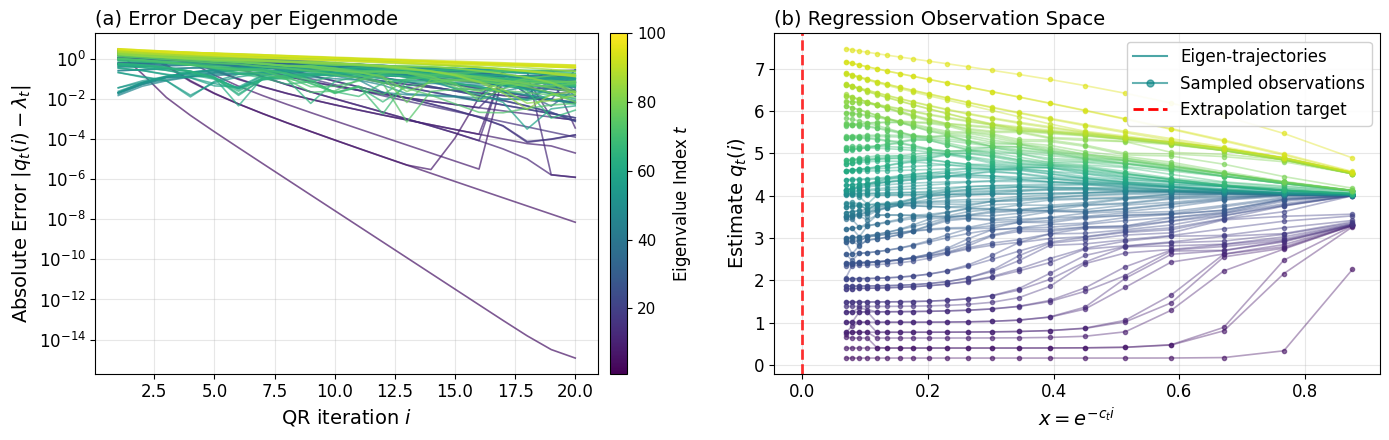

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colors = plt.cm.viridis(np.linspace(0.05, 0.95, n))

# ── Left: absolute errors vs iteration ───────────────────────────────────────
ax = axes[0]
for t in range(n):
    ax.semilogy(W_VALS, np.abs(q_matrix[:, t] - exact[t]) + 1e-16,
                color=colors[t], alpha=0.7, lw=1.2)
ax.set_xlabel(r'QR iteration $i$', fontsize=14)
ax.set_ylabel(r'Absolute Error $|q_t(i) - \lambda_t|$', fontsize=14)
ax.set_title('(a) Error Decay per Eigenmode', fontsize=14, loc='left')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3)

# colorbar
sm = plt.cm.ScalarMappable(
    cmap='viridis',
    norm=plt.Normalize(vmin=1, vmax=n)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Eigenvalue Index $t$', fontsize=12)
cbar.ax.tick_params(labelsize=11)

# ── Right: observations in GP input space ────────────────────────────────────
ax = axes[1]
for t in range(n):
    ax.plot(X_vals, q_matrix[:, t], '-',
            color=colors[t], alpha=0.4, lw=1.2)
    ax.plot(X_vals, q_matrix[:, t], 'o',
            color=colors[t], alpha=0.6, ms=3)

ax.axvline(x=0.0, color='red', ls='--', lw=2, alpha=0.8)

ax.set_xlabel(r'$x = e^{-c_t i}$', fontsize=14)
ax.set_ylabel(r'Estimate $q_t(i)$', fontsize=14)
ax.set_title('(b) Regression Observation Space', fontsize=14, loc='left')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3)

# 右图 legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='teal',  lw=1.5, alpha=0.7,
           label='Eigen-trajectories'),
    Line2D([0], [0], color='teal',  lw=1.5, alpha=0.6,
           marker='o', ms=5, label='Sampled observations'),
    Line2D([0], [0], color='red',   lw=2,   ls='--',
           label='Extrapolation target'),
]
ax.legend(handles=legend_elements, fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig_qr_trajectories.pdf', bbox_inches='tight')
plt.show()

In [ ]:
W_TRIM = 1

q_matrix = q_matrix[W_TRIM:, :]
X_vals   = X_vals[W_TRIM:]
W_VALS   = W_VALS[W_TRIM:]
print(f"       q_matrix: {q_matrix.shape},  "
      f"X_vals ∈ [{X_vals.min():.4f}, {X_vals.max():.4f}]")
print(f"       Task i=1: q ∈ [{q_matrix[:,0].min():.4f}, {q_matrix[:,0].max():.4f}], "
      f"exact={exact[0]:.4f}")


[Trim] 去掉前 1 步迭代 (w=1..1)
       q_matrix: (19, 100),  X_vals ∈ [0.0699, 0.7663]
       Task i=1: q ∈ [0.1620, 0.3337], exact=0.1620


---
## 2. Method 1 — Independent



In [6]:
print("=" * 65)
print("METHOD 1: INDEPENDENT")
print("  Per-task REML hyperparameter optimisation (10 restarts).")
print("  No information shared across eigenvalue indices.")
print("=" * 65)

rng = np.random.default_rng(42)
results_indep = []
for i in range(n):
    X_t = torch.tensor(X_vals, dtype=torch.float64)
    Y_t = torch.tensor(q_matrix[:, i], dtype=torch.float64)
    try:
        amp, ell = fit_reml_single(X_t, Y_t, A, n_restarts=10,rng=rng)
        mu, var  = predict_at_zero(X_vals, q_matrix[:, i], amp, ell, A)
        results_indep.append({
            'amplitude': amp, 'lengthscale': ell,
            'mu': mu, 'var': var, 'success': True,
        })
    except Exception:
        results_indep.append({
            'amplitude': np.nan, 'lengthscale': np.nan,
            'mu': np.nan, 'var': np.nan, 'success': False,
        })

amps_indep = np.array([r['amplitude']   for r in results_indep])
ells_indep = np.array([r['lengthscale'] for r in results_indep])
n_ok = sum(r['success'] for r in results_indep)

print(f"\nSuccessful fits: {n_ok}/{n}")
print(f"  amplitude  σ  ∈ [{amps_indep.min():.3g}, {amps_indep.max():.3g}]")
print(f"  lengthscale ℓ ∈ [{ells_indep.min():.3g}, {ells_indep.max():.3g}]")
print(f"  log-σ spread (std): {np.std(np.log(amps_indep+1e-30)):.3f}")
print(f"  log-ℓ spread (std): {np.std(np.log(ells_indep+1e-30)):.3f}")

METHOD 1: INDEPENDENT
  Per-task REML hyperparameter optimisation (10 restarts).
  No information shared across eigenvalue indices.

Successful fits: 100/100
  amplitude  σ  ∈ [0.00884, 2.98e+03]
  lengthscale ℓ ∈ [0.000335, 33.7]
  log-σ spread (std): 3.800
  log-ℓ spread (std): 3.275


In [ ]:

alphas_indep = apply_holdout_calibration(
    results_indep, X_vals, q_matrix, A,
    k_holdout=K_HOLDOUT,
    kernel_spec=KERNEL,
    label='Independent ',
)

# ── Extract posterior mean and (calibrated) std ───────────────────────────────
mus_indep  = np.array([r['mu']  for r in results_indep])
vars_indep = np.array([r['var'] for r in results_indep])   # calibrated
stds_indep = np.sqrt(np.maximum(vars_indep, 1e-30))

# ── Calibration metrics ───────────────────────────────────────────────────────
met_indep = evaluate(mus_indep, stds_indep, exact)
rmse_indep = float(np.sqrt(np.mean((mus_indep - exact)**2)))

print(f"\n  RMSE               = {rmse_indep:.4e}")
print(f"  Coverage ±2σ       = {met_indep['cov_2s']:.4f}  (target {COV_2SIGMA:.4f})")
print(f"  z-score mean       = {met_indep['z_mean']:+.4f}  (ideal: 0)")
print(f"  z-score std        = {met_indep['z_std']:.4f}   (ideal: 1)")
print(f"  KS stat / p-value  = {met_indep['ks_stat']:.4f} / {met_indep['ks_pval']:.4f}")

  Independent Holdout calibration (k=5): median new_var=1.754e-02, range=[4.10e-04, 3.66e-01], n=100/100

  RMSE               = 1.8008e-01
  Coverage ±2σ       = 0.8500  (target 0.9545)
  z-score mean       = -0.2131  (ideal: 0)
  z-score std        = 2.3141   (ideal: 1)
  KS stat / p-value  = 0.1122 / 0.1490


---
## 3. Method 2 — Global (Geometric Means)


In [ ]:
print("=" * 65)
print("METHOD 2: GLOBAL (GEOMETRIC MEANS)")
print("  Single shared (σ̄, ℓ̄) = geometric mean of independent fits.")
print("  All n eigenvalue tasks use the same hyperparameters.")
print("=" * 65)


amp_global, ell_global = geom_means(amps_indep, ells_indep)
amps_global = np.full(n, amp_global)   # (n,) uniform
ells_global = np.full(n, ell_global)   # (n,) uniform

print(f"\n  σ̄ (global amplitude)  = {amp_global:.4g}")
print(f"  ℓ̄ (global lengthscale) = {ell_global:.4g}")


results_global = predict_with_hyperparams(
    X_vals, q_matrix, amps_global, ells_global, A,
    kernel_spec=KERNEL,
)

METHOD 2: GLOBAL (GEOMETRIC MEANS)
  Single shared (σ̄, ℓ̄) = geometric mean of independent fits.
  All n eigenvalue tasks use the same hyperparameters.

  σ̄ (global amplitude)  = 4.048
  ℓ̄ (global lengthscale) = 0.07082


In [9]:
# ── Holdout extrapolation calibration ─────────────────────────────────────
alphas_global = apply_holdout_calibration(
    results_global, X_vals, q_matrix, A,
    k_holdout=K_HOLDOUT,
    kernel_spec=KERNEL,
    label='Global ',
)

mus_global  = np.array([r['mu']  for r in results_global])
vars_global = np.array([r['var'] for r in results_global])   # calibrated
stds_global = np.sqrt(np.maximum(vars_global, 1e-30))

met_global = evaluate(mus_global, stds_global, exact)
rmse_global = float(np.sqrt(np.mean((mus_global - exact)**2)))

print(f"\n  RMSE               = {rmse_global:.4e}")
print(f"  Coverage ±2σ       = {met_global['cov_2s']:.4f}  (target {COV_2SIGMA:.4f})")
print(f"  z-score mean       = {met_global['z_mean']:+.4f}  (ideal: 0)")
print(f"  z-score std        = {met_global['z_std']:.4f}   (ideal: 1)")
print(f"  KS stat / p-value  = {met_global['ks_stat']:.4f} / {met_global['ks_pval']:.4f}")

  Global Holdout calibration (k=5): median new_var=1.490e-01, range=[5.52e-04, 1.62e+00], n=100/100

  RMSE               = 2.3410e-01
  Coverage ±2σ       = 0.9800  (target 0.9545)
  z-score mean       = -0.1117  (ideal: 0)
  z-score std        = 0.8334   (ideal: 1)
  KS stat / p-value  = 0.1893 / 0.0013


---
## 4. Method 3 — Sequential 



In [ ]:

print("=" * 65)
print("METHOD 3: Sequential SPRE (GRW REGULARISATION)")
print("  Joint GRW optimisation with adjacent-smoothness penalty.")
print("  λ_σ, λ_ℓ fixed from prior search — skipping grid to save time.")
print("=" * 65)


best_lam     = 4.9239e+00   # λ_σ  — amplitude smoothness
best_lam_ell = 9.8478e+00   # λ_ℓ  = 2 × λ_σ  — lengthscale smoothness
GRW_RESTARTS = 5

print(f"Fixed  λ_σ = {best_lam:.4e},  λ_ℓ = {best_lam_ell:.4e}")
print(f"Warm-start from Global HPs:  σ = {amp_global:.4g},  ℓ = {ell_global:.4g}")

# ── Run GRW joint MAP with fixed λ ───────────────────────────────────────────
print(f"\nRunning GRW optimisation ({GRW_RESTARTS} restarts) ...")
amps_trspr, ells_trspr, obj_trspr, diag_trspr = compute_regularised_grw(
    X_vals, q_matrix, best_lam, A,
    kernel_spec  = KERNEL,
    num_restarts = GRW_RESTARTS,
    init_sigmas  = amps_global,
    init_ells    = ells_global,
    lam_ell      = best_lam_ell,
    verbose      = True,
)

# Build sel_grw dict for downstream compatibility (no grid search scores)
sel_grw = dict(
    best_lam_sig       = best_lam,
    best_lam_ell       = best_lam_ell,
    best_score         = None,
    scores             = None,
    cached_hyperparams = (amps_trspr.copy(), ells_trspr.copy()),
)

print(f"\nSequential SPRE hyperparameters:")
print(f"  amplitude  σ  ∈ [{amps_trspr.min():.3g}, {amps_trspr.max():.3g}]")
print(f"  lengthscale ℓ ∈ [{ells_trspr.min():.3g}, {ells_trspr.max():.3g}]")
print(f"  Converged: {diag_trspr['optim_success']},  n_nonfinite: {diag_trspr['n_nonfinite']}")

print("=" * 65)
print("METHOD 3: TR-SPre (TASK-REGULARISED SPRE)")
print("  Joint GRW optimisation with adjacent-smoothness penalty.")
print("λ_σ, λ_ℓ selected by 1-D LOOCV grid search (lam_ell_ratio controls ratio).")
print("=" * 65)

# ── Diagnostic: print what Independent fits look like ────────────────────────
print(f"\n[Diagnostic] Independent amplitudes:")
print(f"  log-σ: min={np.log(amps_indep).min():.2f}, "
      f"max={np.log(amps_indep).max():.2f}, "
      f"std={np.std(np.log(amps_indep+1e-30)):.2f}  ← large std = erratic / collapsed")
print(f"  log-ℓ: min={np.log(ells_indep).min():.2f}, "
      f"max={np.log(ells_indep).max():.2f}, "
      f"std={np.std(np.log(ells_indep+1e-30)):.2f}")

print(f"\n[Fix] Warm-starting GRW from Global (geometric-mean) HPs:")
print(f"  σ_global = {amp_global:.4g},  ℓ_global = {ell_global:.4g}")

# ── Two-lambda settings ──────────────────────────────────────────────────────
LAM_GRID      = np.logspace(-2, 3, 14)  
LAM_ELL_RATIO = 2.0                     
LAM_ELL_GRID  = LAM_GRID * LAM_ELL_RATIO  
print(f"\nSearching over {len(LAM_GRID)} λ_σ values: "
      f"[{LAM_GRID[0]:.2e}, ..., {LAM_GRID[-1]:.2e}]")
print(f"lam_ell_ratio = {LAM_ELL_RATIO}  (lam_ℓ = {LAM_ELL_RATIO} * lam_σ)")

sel_grw = select_regularisation_grw(
    X_vals, q_matrix, LAM_GRID, LAM_ELL_GRID, A,
    kernel_spec  = KERNEL,
    init_sigmas  = amps_global,
    init_ells    = ells_global,
    verbose      = True,
    
)

best_lam     = sel_grw["best_lam_sig"] 
best_lam_ell = sel_grw["best_lam_ell"]
best_score   = sel_grw["best_score"]
print(f"\nSelected λ_σ = {best_lam:.4e},  λ_ℓ = {best_lam_ell:.4e}  (LOOCV score = {best_score:.4f})")

METHOD 3: Sequential SPRE (GRW REGULARISATION)
  Joint GRW optimisation with adjacent-smoothness penalty.
  λ_σ, λ_ℓ fixed from prior search — skipping grid to save time.
Fixed  λ_σ = 4.9239e+00,  λ_ℓ = 9.8478e+00
Warm-start from Global HPs:  σ = 4.048,  ℓ = 0.07082

Running GRW optimisation (5 restarts) ...
  [GRW optim] nfev=217, success=True, n_nonfinite=0

Sequential SPRE hyperparameters:
  amplitude  σ  ∈ [0.0385, 2.98e+03]
  lengthscale ℓ ∈ [0.0206, 3.03]
  Converged: True,  n_nonfinite: 0
METHOD 3: TR-SPre (TASK-REGULARISED SPRE)
  Joint GRW optimisation with adjacent-smoothness penalty.
λ_σ, λ_ℓ selected by 1-D LOOCV grid search (lam_ell_ratio controls ratio).

[Diagnostic] Independent amplitudes:
  log-σ: min=-4.73, max=8.00, std=3.80  ← large std = erratic / collapsed
  log-ℓ: min=-8.00, max=3.52, std=3.27

[Fix] Warm-starting GRW from Global (geometric-mean) HPs:
  σ_global = 4.048,  ℓ_global = 0.07082

Searching over 14 λ_σ values: [1.00e-02, ..., 1.00e+03]
lam_ell_ratio = 

In [11]:

# ── λ selection summary (fixed values — no grid search) ──────────────────────
print(f"Sequential SPRE regularisation parameters (fixed):")
print(f"  λ_σ = {best_lam:.4e}   (amplitude smoothness)")
print(f"  λ_ℓ = {best_lam_ell:.4e}   (lengthscale smoothness)")
print(f"  λ_ℓ / λ_σ = {best_lam_ell / best_lam:.2f}")
print(f"  Optimisation: converged={diag_trspr['optim_success']}, "
      f"n_nonfinite={diag_trspr['n_nonfinite']}")


Sequential SPRE regularisation parameters (fixed):
  λ_σ = 1.0000e+03   (amplitude smoothness)
  λ_ℓ = 2.0000e+03   (lengthscale smoothness)
  λ_ℓ / λ_σ = 2.00
  Optimisation: converged=True, n_nonfinite=0


In [12]:

# ── Diagnostics for Sequential SPRE hyperparameters ──────────────────────────
# amps_trspr, ells_trspr already computed in the cell above (fixed λ run).
print(f"Sequential hyperparameters  (λ_σ={best_lam:.4e}, λ_ℓ={best_lam_ell:.4e}):")
print(f"  amplitude  σ  ∈ [{amps_trspr.min():.3g}, {amps_trspr.max():.3g}]")
print(f"  lengthscale ℓ ∈ [{ells_trspr.min():.3g}, {ells_trspr.max():.3g}]")
print(f"  log-σ spread: {np.std(np.log(amps_trspr + 1e-30)):.3f}  "
      f"(Independent: {np.std(np.log(amps_indep + 1e-30)):.3f}, "
      f"Global: {np.std(np.log(amps_global + 1e-30)):.3f})")
print(f"  log-ℓ spread: {np.std(np.log(ells_trspr + 1e-30)):.3f}  "
      f"(Independent: {np.std(np.log(ells_indep + 1e-30)):.3f}, "
      f"Global: {np.std(np.log(ells_global + 1e-30)):.3f})")

# Predict at X=0 with the Sequential hyperparameters
results_trspr = predict_with_hyperparams(
    X_vals, q_matrix, amps_trspr, ells_trspr, A,
    kernel_spec=KERNEL,
)


Sequential hyperparameters  (λ_σ=1.0000e+03, λ_ℓ=2.0000e+03):
  amplitude  σ  ∈ [0.0385, 2.98e+03]
  lengthscale ℓ ∈ [0.0206, 3.03]
  log-σ spread: 2.890  (Independent: 3.800, Global: 0.000)
  log-ℓ spread: 1.176  (Independent: 3.275, Global: 0.000)


In [13]:
# ── Holdout extrapolation calibration ─────────────────────────────────────
alphas_trspr = apply_holdout_calibration(
    results_trspr, X_vals, q_matrix, A,
    k_holdout=K_HOLDOUT,
    kernel_spec=KERNEL,
    label='Sequential ',
)

mus_trspr  = np.array([r['mu']  for r in results_trspr])
vars_trspr = np.array([r['var'] for r in results_trspr])   # calibrated
stds_trspr = np.sqrt(np.maximum(vars_trspr, 1e-30))

met_trspr = evaluate(mus_trspr, stds_trspr, exact)
rmse_trspr = float(np.sqrt(np.mean((mus_trspr - exact)**2)))

print(f"\n  RMSE               = {rmse_trspr:.4e}")
print(f"  Coverage ±2σ       = {met_trspr['cov_2s']:.4f}  (target {COV_2SIGMA:.4f})")
print(f"  z-score mean       = {met_trspr['z_mean']:+.4f}  (ideal: 0)")
print(f"  z-score std        = {met_trspr['z_std']:.4f}   (ideal: 1)")
print(f"  KS stat / p-value  = {met_trspr['ks_stat']:.4f} / {met_trspr['ks_pval']:.4f}")

  Sequential Holdout calibration (k=5): median new_var=1.725e-02, range=[4.73e-04, 8.55e-01], n=100/100

  RMSE               = 1.6361e-01
  Coverage ±2σ       = 0.8700  (target 0.9545)
  z-score mean       = -0.1379  (ideal: 0)
  z-score std        = 1.8502   (ideal: 1)
  KS stat / p-value  = 0.1683 / 0.0060


---
## 4. Method 4 — LMC (Linear Model of Coregionalisation)

**Model.** All $n$ eigenvalue tasks share a Matérn-3/2 base kernel via a rank-$p$ coregionalisation
matrix $W = BB^\top$:

$$f_i(x) = m_i(x) + \sum_{j=1}^p B_{ij}\, g_j(x), \quad g_j \sim \mathcal{GP}(0,\, k_{\sigma,\ell})$$

**Cross-covariance:** $\operatorname{Cov}(f_i(x),\, f_{i'}(x')) = W_{ii'} \cdot k(x,x')$

**Inference** uses the Kronecker structure $K_{\rm joint} = W \otimes K_{\rm base} + \sigma^2 I_{Tn}$:
storage and inference cost reduce from $O((Tn)^2)$ and $O((Tn)^3)$ to $O(T^2 + n^2)$ and $O(T^3 + n^3)$.

Each task has its own polynomial mean (intercept + linear), estimated jointly.


In [14]:
print("=" * 65)
print("METHOD 4: LMC (Linear Model of Coregionalisation)")
print("  Rank-2 coregionalisation matrix B @ B.T")
print("  Shared Matern-3/2 base kernel, per-task polynomial mean")
print("  Prediction via Kronecker eigendecomposition")
print("=" * 65)

LMC_RANK     = 2
LMC_RESTARTS = 5

lmc_result = run_lmc_baseline(
    X_vals, q_matrix, exact,
    rank        = LMC_RANK,
    poly_order  = POLY_ORDER,
    kernel_spec = KERNEL, 
    n_restarts  = LMC_RESTARTS,
    verbose     = True,
)

mus_lmc  = lmc_result['mu']
stds_lmc = lmc_result['std']
met_lmc  = lmc_result['metrics']
rmse_lmc = float(np.sqrt(np.mean((mus_lmc - exact)**2)))

print(f"\n  RMSE               = {rmse_lmc:.4e}")
print(f"  Coverage \u00b12\u03c3       = {met_lmc['cov_2s']:.4f}  (target {COV_2SIGMA:.4f})")
print(f"  z-score mean       = {met_lmc['z_mean']:+.4f}  (ideal: 0)")
print(f"  z-score std        = {met_lmc['z_std']:.4f}   (ideal: 1)")
print(f"  KS stat / p-value  = {met_lmc['ks_stat']:.4f} / {met_lmc['ks_pval']:.4f}")
print(f"  LMC amp={lmc_result['amp']:.4g}  ell={lmc_result['ell']:.4g}  noise={lmc_result['noise']:.2e}")


METHOD 4: LMC (Linear Model of Coregionalisation)
  Rank-2 coregionalisation matrix B @ B.T
  Shared Matern-3/2 base kernel, per-task polynomial mean
  Prediction via Kronecker eigendecomposition
[LMC] Fitting rank-2 LMC  (Matern3/2, T=100 tasks, n=19 obs, restarts=5) …
[LMC] amp=54.6  ell=0.04717  noise=0 (fixed)  NLL=7101816745.9292
[LMC] Cov±2σ=0.820  z_mean=+88.397  z_std=837.338  KS=0.154

  RMSE               = 2.2635e-01
  Coverage ±2σ       = 0.8200  (target 0.9545)
  z-score mean       = +88.3971  (ideal: 0)
  z-score std        = 837.3385   (ideal: 1)
  KS stat / p-value  = 0.1535 / 0.0160
  LMC amp=54.6  ell=0.04717  noise=0.00e+00


---
## 5. Method 5 — SLFM (Semiparametric Latent Factor Model)

**Model.** $p$ independent latent GPs, each with its own kernel $(\sigma_j, \ell_j)$:
$$
f_t(x) = \sum_{j=1}^p c_{tj}\,g_j(x),\quad g_j \sim \mathcal{GP}(0, k_j)
$$
Joint covariance: $K = \sum_j (c_j c_j^\top) \otimes K_j + \sigma_n^2 I$  (full $Tn\times Tn$, **no Kronecker**).

**Difference from LMC/ICM:** every factor has its own $(\sigma_j, \ell_j)$, breaking the shared-kernel assumption.

_Reference: Teh, Seeger & Jordan, AISTATS 2005._

In [ ]:
print("=" * 65)
print("METHOD 5: SLFM (Semiparametric Latent Factor Model, Teh 2005)")
print("  f_t = sum_j c_tj g_j,  g_j ~ GP(0, k_j),  own (sigma_j, ell_j)")
print("  Full Tn x Tn covariance — no Kronecker approximation")
print("=" * 65)

SLFM_RANK     = 2
SLFM_RESTARTS = 5

slfm_result = run_slfm_baseline(
    X_vals, q_matrix, exact,
    rank        = SLFM_RANK,
    poly_order  = POLY_ORDER,
    n_restarts  = SLFM_RESTARTS,
    verbose     = True,
)

mus_slfm  = slfm_result['mu']
stds_slfm = slfm_result['std']
met_slfm  = slfm_result['metrics']
rmse_slfm = float(np.sqrt(np.mean((mus_slfm - exact)**2)))

print(f"\n  RMSE               = {rmse_slfm:.4e}")
print(f"  Coverage \u00b12\u03c3       = {met_slfm['cov_2s']:.4f}  (target {COV_2SIGMA:.4f})")
print(f"  z-score mean       = {met_slfm['z_mean']:+.4f}  (ideal: 0)")
print(f"  z-score std        = {met_slfm['z_std']:.4f}   (ideal: 1)")
print(f"  KS stat / p-value  = {met_slfm['ks_stat']:.4f} / {met_slfm['ks_pval']:.4f}")
print(f"  amps={np.round(slfm_result['amps'],4)}  ells={np.round(slfm_result['ells'],4)}  noise={slfm_result['noise']:.2e}")

METHOD 5: SLFM (Semiparametric Latent Factor Model, Teh 2005)
  f_t = sum_j c_tj g_j,  g_j ~ GP(0, k_j),  own (sigma_j, ell_j)
  Full Tn x Tn covariance — no Kronecker approximation
[SLFM] Fitting rank-2 SLFM  (Matern3/2, T=100 tasks, n=19 obs, restarts=5) ...
[SLFM] amps=[1.1026 1.5378]  ells=[0.3644 0.3246]  noise=0 (fixed)  NLL=1000000000000.0000
[SLFM] Cov±2σ=0.550  z_mean=-2.238  z_std=14.239  KS=0.235

  RMSE               = 2.0829e-01
  Coverage ±2σ       = 0.5500  (target 0.9545)
  z-score mean       = -2.2385  (ideal: 0)
  z-score std        = 14.2392   (ideal: 1)
  KS stat / p-value  = 0.2350 / 0.0000
  amps=[1.1026 1.5378]  ells=[0.3644 0.3246]  noise=0.00e+00


### 5.2 Hyperparameter Profiles

Shows how the three methods allocate $(\sigma_i, \ell_i)$ across eigenvalue index.

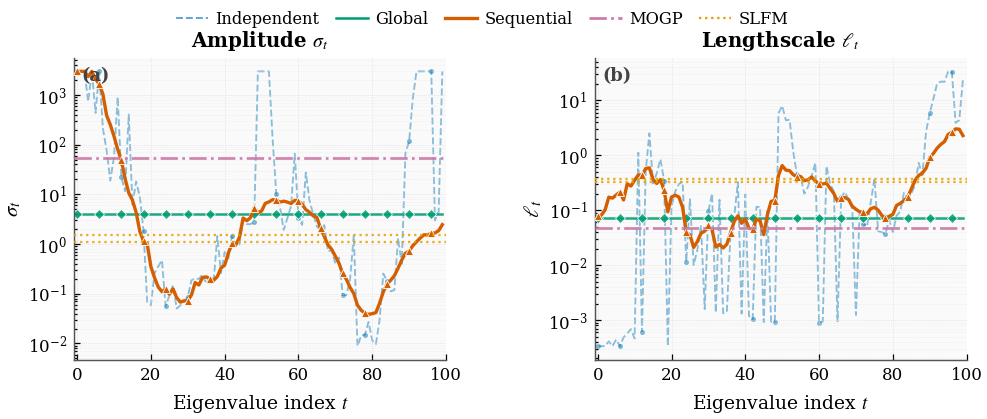

In [ ]:


import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":    "stix",
    "font.size":           9,
    "axes.titlesize":      9.5,
    "axes.labelsize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "legend.fontsize":     8,

    "axes.linewidth":      0.75,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.edgecolor":      "#555555",
    "figure.facecolor":    "white",
    "axes.facecolor":      "#fafafa",

    "axes.grid":           True,
    "grid.color":          "#d8d8d8",
    "grid.linewidth":      0.35,
    "grid.linestyle":      ":",
    "grid.alpha":          1.0,

    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.major.width":   0.6,
    "ytick.major.width":   0.6,

    "legend.framealpha":   0.0,
    "legend.edgecolor":    "none",
    "legend.borderpad":    0.4,
    "legend.labelspacing": 0.25,

    "figure.dpi":          150,
    "savefig.dpi":         300,
    "savefig.pad_inches":  0.03,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

C_IND = "#0072B2"   # deep blue   — Independent
C_GLO = "#009E73"   # teal        — Global
C_SEQ = "#D55E00"   # vermillion  — Sequential
C_LMC = "#CC79A7"   # mauve       — LMC/MOGP
C_SLF = "#E69F00"   # amber       — SLFM

lam_str = f"{best_lam:.3g}"
idx     = np.arange(n)
mev     = max(1, n // 16)


PANELS = [
    (amps_indep, amps_global, amps_trspr,
     r"$\sigma_t$",  r"Amplitude $\sigma_t$",  "(a)"),
    (ells_indep, ells_global, ells_trspr,
     r"$\ell_t$",    r"Lengthscale $\ell_t$",  "(b)"),
]


fig, axes = plt.subplots(
    1, 2,
    figsize=(6.8, 3.1),
    sharey=False,
)
fig.subplots_adjust(
    wspace=0.40,
    top=0.82,     
    bottom=0.17,
    left=0.10,
    right=0.975,
)


for ax, (vi, vg, vt, ylabel, col_title, plabel) in zip(axes, PANELS):

    
    ax.semilogy(idx, vi, "--",
                color=C_IND, lw=0.9, alpha=0.45, zorder=1,
                solid_capstyle="round")
    ax.semilogy(idx, vi, "o",
                color=C_IND, ms=2.4, alpha=0.50, zorder=1,
                markeredgewidth=0, markevery=mev)

    
    ax.semilogy(idx, vg, "-",
                color=C_GLO, lw=1.2, alpha=0.88, zorder=2)
    ax.semilogy(idx, vg, "D",
                color=C_GLO, ms=3.5, alpha=0.88, zorder=2,
                markeredgewidth=0.4, markeredgecolor="white",
                markevery=mev)

    
    ax.semilogy(idx, vt, "-",
                color=C_SEQ, lw=1.6, alpha=1.0, zorder=3)
    ax.semilogy(idx, vt, "^",
                color=C_SEQ, ms=4.2, alpha=1.0, zorder=3,
                markeredgewidth=0.4, markeredgecolor="white",
                markevery=mev)


    scalar_val = lmc_result['amp'] if plabel == '(a)' else lmc_result['ell']
    ax.axhline(scalar_val, color=C_LMC, lw=1.3, ls='-.',
               alpha=0.92, zorder=4)

   
    slfm_vals = slfm_result['amps'] if plabel == '(a)' else slfm_result['ells']
    for sv in slfm_vals:
        ax.axhline(sv, color=C_SLF, lw=1.1, ls=':',
                   alpha=0.85, zorder=5)

    
    ax.set_xlabel(r"Eigenvalue index $t$", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=2)
    ax.set_title(col_title, fontsize=9.5, fontweight="semibold", pad=5)
    ax.set_xlim(-0.8, n)          
    ax.xaxis.set_major_locator(mticker.MultipleLocator(20))   # 0,20,40…100


    ax.text(0.02, 0.97, plabel,
            transform=ax.transAxes,
            fontsize=8.5, fontweight="bold",
            va="top", ha="left", color="#444444")

  
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs="all", numticks=10))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(which="minor", color="#e4e4e4", linewidth=0.25, linestyle=":")


    ax.tick_params(which="both", direction="in", width=0.6)
    ax.tick_params(which="major", length=3.0)
    ax.tick_params(which="minor", length=1.5)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.7)
        ax.spines[spine].set_color("#555555")

legend_elements = [
    Line2D([0], [0], color=C_IND, lw=0.9, ls='--',
           alpha=0.65, label='Independent'),
    Line2D([0], [0], color=C_GLO, lw=1.2, ls='-',
           label='Global'),
    Line2D([0], [0], color=C_SEQ, lw=1.6, ls='-',
           label='Sequential'),
    Line2D([0], [0], color=C_LMC, lw=1.3, ls='-.',
           label='MOGP'),
    Line2D([0], [0], color=C_SLF, lw=1.1, ls=':',
           label='SLFM'),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.50, 0.952),
    ncol=5,
    fontsize=7.8,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.0,
    handletextpad=0.45,
)


plt.savefig("QRHYPonetwo.pdf", bbox_inches="tight")
plt.savefig("QRHYPonetwo.png", dpi=300, bbox_inches="tight")
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)